In [132]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [133]:
import json
import pandas as pd
import numpy as np

# ---- Load baseline results ----
with open(r"D:\programming\rPPg\cv_2\cv2_output.json","r") as f:
    baseline_data = json.load(f)["subjects"]

# ---- Load drift results ----
with open("hr_results.json","r") as f:
    drift_data = json.load(f)

# ---- Load ground truth ----
with open(r"D:\programming\rPPg\evaluation\all_subjects_hr.json","r") as f:
    gt_data = json.load(f)

rows = []

for subject in baseline_data:

    if subject not in drift_data:
        continue

    rows.append({

        "Subject": subject,

        "Baseline_HR": baseline_data[subject]["hr_bpm"],

        "Forehead_raw": drift_data[subject]["forehead"]["hr_before_drift"],
        "LeftCheek_raw": drift_data[subject]["left_cheek"]["hr_before_drift"],
        "RightCheek_raw": drift_data[subject]["right_cheek"]["hr_before_drift"],

        "Forehead_clean": drift_data[subject]["forehead"]["hr_after_drift"],
        "LeftCheek_clean": drift_data[subject]["left_cheek"]["hr_after_drift"],
        "RightCheek_clean": drift_data[subject]["right_cheek"]["hr_after_drift"],

        "Final_HR": drift_data[subject]["final_hr"],

        "Real_HR": gt_data[subject]["real_heart_rate_bpm"]

    })

df = pd.DataFrame(rows)

print("Loaded subjects:", len(df))
df.head()

Loaded subjects: 17


,Subject,Baseline_HR,Forehead_raw,LeftCheek_raw,RightCheek_raw,Forehead_clean,LeftCheek_clean,RightCheek_clean,Final_HR,Real_HR
0,Subject_1,52.00,88.14,87.14,98.15,93.70,89.71,96.02,93.70,96.681960
1,Subject_2,121.45,90.20,88.86,82.85,90.20,90.35,82.85,90.20,106.704568
2,Subject_3,92.53,89.60,86.87,85.23,91.00,92.31,85.23,91.00,101.170444
3,Subject_4,90.91,85.53,100.53,99.78,84.81,100.53,99.78,99.78,112.273904
4,Subject_5,111.75,111.33,85.25,90.27,111.18,91.01,92.43,92.43,111.243833


In [134]:
df["ROI_mean"] = df[
["Forehead_clean","LeftCheek_clean","RightCheek_clean"]
].mean(axis=1)

df["ROI_std"] = df[
["Forehead_clean","LeftCheek_clean","RightCheek_clean"]
].std(axis=1)

df["ROI_range"] = df[[
"Forehead_clean","LeftCheek_clean","RightCheek_clean"
]].max(axis=1) - df[[
"Forehead_clean","LeftCheek_clean","RightCheek_clean"
]].min(axis=1)

df["Drift_correction"] = abs(df["ROI_mean"] - df["Forehead_raw"])

df["Raw_clean_diff"] = abs(df["ROI_mean"] - df["Forehead_raw"])

ML inputs

In [135]:
X = df[
[
"Forehead_raw",
"LeftCheek_raw",
"RightCheek_raw",
"Forehead_clean",
"LeftCheek_clean",
"RightCheek_clean",
"ROI_mean",
"ROI_std",
"ROI_range",
"Drift_correction",
"Raw_clean_diff"
]
]

df["Correction"] = df["Real_HR"] - df["Final_HR"]
y = df["Correction"]

In [136]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.25,random_state=42
)
model = RandomForestRegressor(
    n_estimators=800,
    max_depth=10,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42
)

model.fit(X_train,y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=4,
                      n_estimators=800, random_state=42)

In [137]:
pred_correction = model.predict(X_test)

ml_hr = df.loc[X_test.index,"Final_HR"] + pred_correction

In [138]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Baseline predictions for test subjects
baseline_pred = df.loc[X_test.index, "Baseline_HR"]

# Drift predictions for test subjects
drift_pred = df.loc[X_test.index, "Final_HR"]

# Ground truth
real = y_test + df.loc[X_test.index,"Final_HR"]

ml_pred = ml_hr

# ---- MAE ----
baseline_mae = mean_absolute_error(real, baseline_pred)
drift_mae = mean_absolute_error(real, drift_pred)
ml_mae = mean_absolute_error(real, pred)

# ---- RMSE ----
baseline_rmse = np.sqrt(mean_squared_error(real, baseline_pred))
drift_rmse = np.sqrt(mean_squared_error(real, drift_pred))
ml_rmse = np.sqrt(mean_squared_error(real, pred))

print("Baseline MAE:", round(baseline_mae,2))
print("Drift MAE:", round(drift_mae,2))
print("ML MAE:", round(ml_mae,2))

print("Baseline RMSE:", round(baseline_rmse,2))
print("Drift RMSE:", round(drift_rmse,2))
print("ML RMSE:", round(ml_rmse,2))

Baseline MAE: 20.71
Drift MAE: 9.84
ML MAE: 11.56
Baseline RMSE: 28.1
Drift RMSE: 13.44
ML RMSE: 12.88


Compare all methods

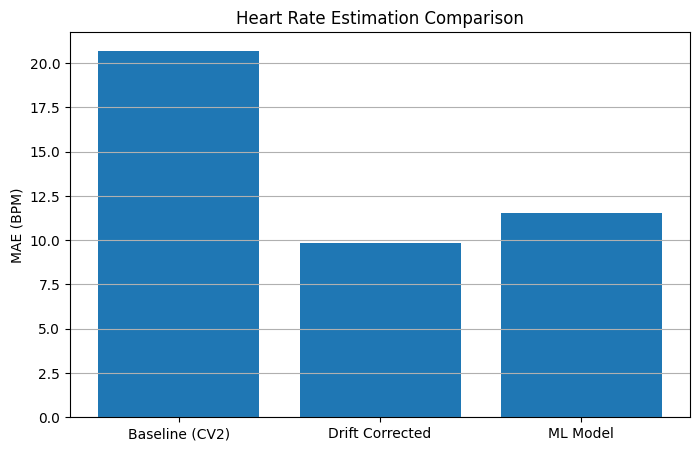

In [139]:
import matplotlib.pyplot as plt

methods = ["Baseline (CV2)", "Drift Corrected", "ML Model"]
errors = [baseline_mae, drift_mae, ml_mae]

plt.figure(figsize=(8,5))
plt.bar(methods, errors)

plt.ylabel("MAE (BPM)")
plt.title("Heart Rate Estimation Comparison")

plt.grid(axis="y")

plt.show()

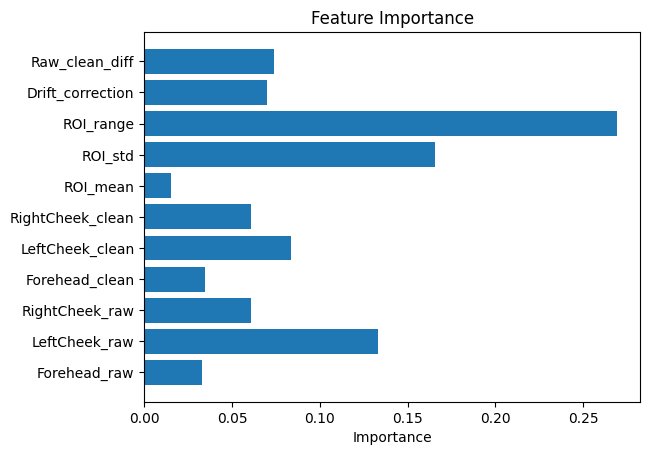

In [140]:
import matplotlib.pyplot as plt

importances = model.feature_importances_

plt.barh(X.columns, importances)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()